<a href="https://colab.research.google.com/github/hgmhd7/AI-Machine-Learning/blob/main/Neural_Networks_1_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MNIST dataset, simple fully connected neural network with 3 layers

Our objective is to set up a neural network problem using the MNIST dataset (https://www.tensorflow.org/datasets/catalog/mnist), which is commonly used for classifying handwritten digits. We'll implement a fully connected (FC) neural network and test three different combinations of activation functions, optimizers, regularizers, and loss functions.

Here's the plan for three different models:

Dataset MNIST provides input of size 28x28.

Let's use dense layers of size 128, 64 and 10 (3 layers) for all the 3 models.
1. Model 1: Basic Model
Activation Function: ReLU for hidden layers, Softmax for output
Optimizer: Stochastic Gradient Descent (SGD)
Regularizer: None
Loss Function: Categorical Crossentropy
2. Model 2: Intermediate Model
Activation Function: Leaky ReLU for hidden layers, Softmax for output
Optimizer: Adam
Regularizer: L2 regularization
Loss Function: Categorical Crossentropy
3. Model 3: Advanced Model
Activation Function: Swish for hidden layers, Softmax for output
Optimizer: Adam with learning rate decay
Regularizer: Dropout
Loss Function: Categorical Crossentropy

Steps:
Data Preparation: We'll load and preprocess the MNIST dataset.
Model Definition: Three models will be created with the configurations mentioned above.
Training: Train the models and track metrics like loss and accuracy.
Evaluation: Compare the performance of the three models

MNIST is a simple dataset. The expectation is that though all 3 models might produce a high accuracy, model 3 might perform better than model 2, and model 2 might perform better than model 1. (It need not be true all the time, due to the simple nature of this dataset)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import CategoricalCrossentropy

def create_model_1():
    # ============================================================
    # Model: Basic Neural Network
    # Specifications:
    # - Hidden layer activation: ReLU
    # - Output layer activation: Softmax
    # - Optimizer: Stochastic Gradient Descent (SGD)
    # - Regularizer: None
    # - Loss function: Categorical Crossentropy
    # ============================================================

    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(28*28,)),
        # First hidden layer with 128 units and ReLU activation
        Dense(128, activation='relu'),

        # Second hidden layer with 64 units and ReLU activation
        Dense(64, activation='relu'),

        # Output layer with 10 units (for 10 classes) and softmax activation
        # Softmax outputs a probability distribution over the classes
        Dense(10, activation='softmax')
    ])

    # Compile the model:
    # - Optimizer: Stochastic Gradient Descent (SGD)
    # - Loss function: Categorical Crossentropy (used for multi-class classification)
    # - Metric: Accuracy (used to evaluate model performance)
    model.compile(
        optimizer=SGD(),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [3]:
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.regularizers import l2

def create_model_2():
    # ============================================================
    # Model: Intermediate Neural Network with L2 Regularization
    # Specifications:
    # - Hidden layer activation: Leaky ReLU
    # - Output layer activation: Softmax
    # - Optimizer: Adam (default learning rate)
    # - Regularizer: L2 kernel regularization
    # - Loss function: Categorical Crossentropy
    # ============================================================

    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(28*28,)),
        # First hidden layer with 128 units, Leaky ReLU activation, and L2 regularization
        Dense(128, kernel_regularizer=l2(0.001)),
        LeakyReLU(),  # Apply Leaky ReLU activation separately for better flexibility

        # Second hidden layer with 64 units, Leaky ReLU activation, and L2 regularization
        Dense(64, kernel_regularizer=l2(0.001)),
        LeakyReLU(),

        # Output layer with 10 units (one per class) using softmax activation
        # Softmax ensures the output forms a valid probability distribution
        Dense(10, activation='softmax')
    ])

    # Compile the model:
    # - Optimizer: Adam (efficient, adaptive gradient descent)
    # - Loss: Categorical Crossentropy (multi-class classification with one-hot labels)
    # - Metric: Accuracy (tracks performance during training/evaluation)
    model.compile(
        optimizer=Adam(),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers.schedules import ExponentialDecay

def create_model_3():
    # ============================================================
    # Model: Advanced Neural Network with Dropout & Swish
    # Specifications:
    # - Hidden layer activation: Swish
    # - Output layer activation: Softmax
    # - Optimizer: Adam with learning rate decay
    # - Regularization: Dropout
    # - Loss function: Categorical Crossentropy
    # ============================================================

    # Define an exponentially decaying learning rate schedule for the Adam optimizer.
    # Starts at 0.001 and decays by 10% every 10,000 steps (staircase decay).
    lr_schedule = ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        decay_rate=0.9,
        staircase=True
    )

    # Build the model using the Sequential API
    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(28*28,)),
        # First hidden layer with 128 units and Swish activation
        Dense(128, activation='swish'),
        # Dropout to reduce overfitting by randomly dropping 30% of the units
        Dropout(0.3),

        # Second hidden layer with 64 units and Swish activation
        Dense(64, activation='swish'),
        # Dropout again to regularize this layer
        Dropout(0.3),

        # Output layer with 10 units (one for each class) and softmax activation
        # Softmax ensures output is a valid probability distribution
        Dense(10, activation='softmax')
    ])

    # Compile the model using:
    # - Adam optimizer with the defined learning rate decay
    # - Categorical crossentropy (used for multi-class classification with one-hot labels)
    # - Accuracy as the metric to monitor
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

Model 1 (Basic Model):


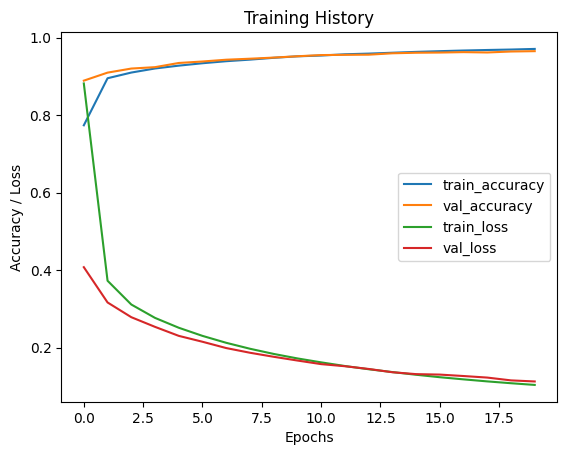

Test accuracy: 0.9649, Test loss: 0.1125

Model 2 (Intermediate Model):


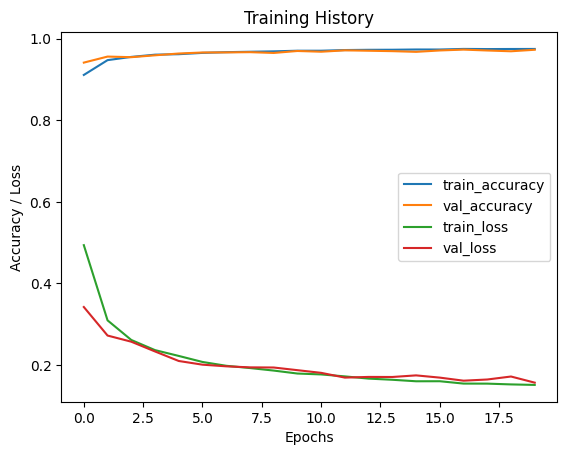

Test accuracy: 0.9730, Test loss: 0.1566

Model 3 (Advanced Model):


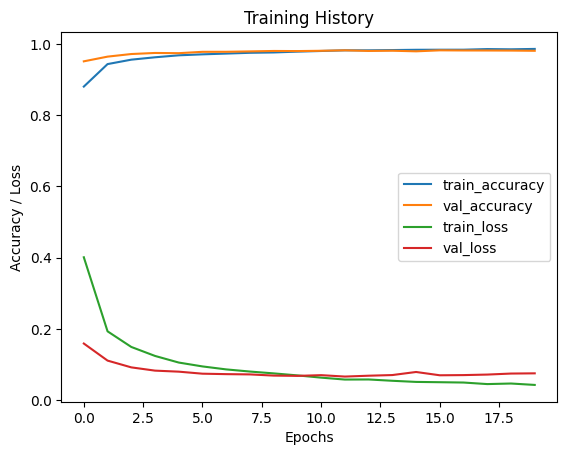

Test accuracy: 0.9806, Test loss: 0.0749


In [5]:
def train_and_plot(model, x_train, y_train, x_test, y_test, epochs=20, batch_size=64):
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=epochs, batch_size=batch_size, verbose=0)

    # Plot the accuracy and loss
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Training History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy / Loss')
    plt.legend()
    plt.show()

    # Evaluate the model
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy: {accuracy:.4f}, Test loss: {loss:.4f}")

# Train and plot for all models
print("Model 1 (Basic Model):")
model_1 = create_model_1()
train_and_plot(model_1, x_train, y_train, x_test, y_test)

print("\nModel 2 (Intermediate Model):")
model_2 = create_model_2()
train_and_plot(model_2, x_train, y_train, x_test, y_test)

print("\nModel 3 (Advanced Model):")
model_3 = create_model_3()
train_and_plot(model_3, x_train, y_train, x_test, y_test)

# CIFAR-10 with similar network

Now let's look at a more complex dataset and let's see whether it can be addressed using the similar neural network(s).

CIFAR-10 consists of 60,000 color images in 10 classes, with 6,000 images per class. The CIFAR-10 dataset is a more challenging classification problem than MNIST due to the diversity and complexity of the images.

* When working with the MNIST dataset, the images are 28x28 grayscale images (i.e., single-channel). In a basic fully connected (FC) network, you flatten the 2D image (28x28) into a 1D vector of 784 elements before passing it to the dense layers.
* However, if we don't explicitly add the Flatten() layer in some frameworks (like TensorFlow), it may be inferred implicitly, especially for simple datasets like MNIST because the data is 2D (28x28). So, you might not have noticed the need for Flatten() in MNIST if it's handled automatically.



* In the case of CIFAR-10, the images are 32x32 with 3 color channels (RGB), meaning the shape of each image is (32, 32, 3). Before passing this 3D image to fully connected layers, you need to explicitly flatten the image into a 1D vector of 32*32*3 = 3,072 elements.

* If you don’t flatten the image in CIFAR-10, the fully connected layer won’t know how to process the multi-dimensional (3D) image data directly. Unlike in the MNIST case, it’s less likely that this will be inferred automatically.


So our first layer in this scenario can be tf.keras.layers.Flatten(input_shape=(32, 32, 3)). This can be followed by fully connected layers of size 512, 256 and 10 respectively

In this scenario too, create 3 models as per the configuration mentioned above and let's compare them

In [6]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the data to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class labels to one-hot encoded vectors
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test)


In [7]:
from tensorflow.keras.layers import Flatten

def create_model_1():
    # ============================================================
    # Model: Basic Neural Network
    # Specifications:
    # - Hidden layer activation: ReLU
    # - Output layer activation: Softmax
    # - Optimizer: Stochastic Gradient Descent (SGD)
    # - Regularizer: None
    # - Loss function: Categorical Crossentropy
    # ============================================================

    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(32, 32, 3)),
        # Flatten the input to a 1D vector
        Flatten(),
        # First hidden layer with 128 units and ReLU activation
        Dense(512, activation='relu'),

        # Second hidden layer with 64 units and ReLU activation
        Dense(256, activation='relu'),

        # Output layer with 10 units (for 10 classes) and softmax activation
        # Softmax outputs a probability distribution over the classes
        Dense(10, activation='softmax')
    ])

    # Compile the model:
    # - Optimizer: Stochastic Gradient Descent (SGD)
    # - Loss function: Categorical Crossentropy (used for multi-class classification)
    # - Metric: Accuracy (used to evaluate model performance)
    model.compile(
        optimizer=SGD(),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [8]:
def create_model_2():
    # ============================================================
    # Model: Intermediate Neural Network with L2 Regularization
    # Specifications:
    # - Hidden layer activation: Leaky ReLU
    # - Output layer activation: Softmax
    # - Optimizer: Adam (default learning rate)
    # - Regularizer: L2 kernel regularization
    # - Loss function: Categorical Crossentropy
    # ============================================================

    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(32, 32, 3)),
        # Flatten the input to a 1D vector
        Flatten(),
        # First hidden layer with 128 units, Leaky ReLU activation, and L2 regularization
        Dense(512, kernel_regularizer=l2(0.001)),
        LeakyReLU(),  # Apply Leaky ReLU activation separately for better flexibility

        # Second hidden layer with 64 units, Leaky ReLU activation, and L2 regularization
        Dense(256, kernel_regularizer=l2(0.001)),
        LeakyReLU(),

        # Output layer with 10 units (one per class) using softmax activation
        # Softmax ensures the output forms a valid probability distribution
        Dense(10, activation='softmax')
    ])

    # Compile the model:
    # - Optimizer: Adam (efficient, adaptive gradient descent)
    # - Loss: Categorical Crossentropy (multi-class classification with one-hot labels)
    # - Metric: Accuracy (tracks performance during training/evaluation)
    model.compile(
        optimizer=Adam(),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [9]:
def create_model_3():
    # ============================================================
    # Model: Advanced Neural Network with Dropout & Swish
    # Specifications:
    # - Hidden layer activation: Swish
    # - Output layer activation: Softmax
    # - Optimizer: Adam with learning rate decay
    # - Regularization: Dropout
    # - Loss function: Categorical Crossentropy
    # ============================================================

    # Define an exponentially decaying learning rate schedule for the Adam optimizer.
    # Starts at 0.001 and decays by 10% every 10,000 steps (staircase decay).
    lr_schedule = ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        decay_rate=0.9,
        staircase=True
    )

    # Build the model using the Sequential API
    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(32, 32, 3)),
        # Flatten the input to a 1D vector
        Flatten(),
        # First hidden layer with 128 units and Swish activation
        Dense(512, activation='swish'),
        # Dropout to reduce overfitting by randomly dropping 30% of the units
        Dropout(0.3),

        # Second hidden layer with 64 units and Swish activation
        Dense(256, activation='swish'),
        # Dropout again to regularize this layer
        Dropout(0.3),

        # Output layer with 10 units (one for each class) and softmax activation
        # Softmax ensures output is a valid probability distribution
        Dense(10, activation='softmax')
    ])

    # Compile the model using:
    # - Adam optimizer with the defined learning rate decay
    # - Categorical crossentropy (used for multi-class classification with one-hot labels)
    # - Accuracy as the metric to monitor
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

Model 1 (Basic Model):


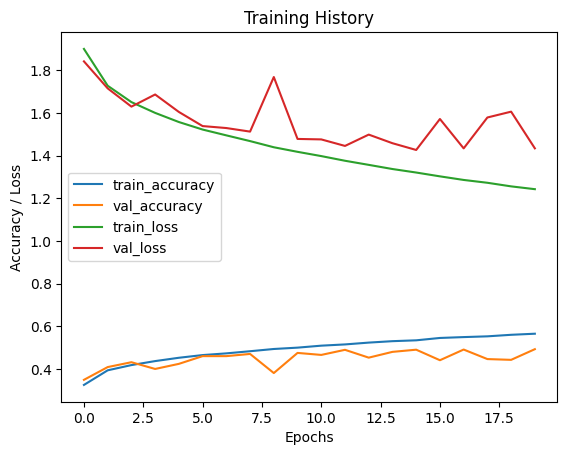

Test accuracy: 0.4925, Test loss: 1.4340

Model 2 (Intermediate Model):


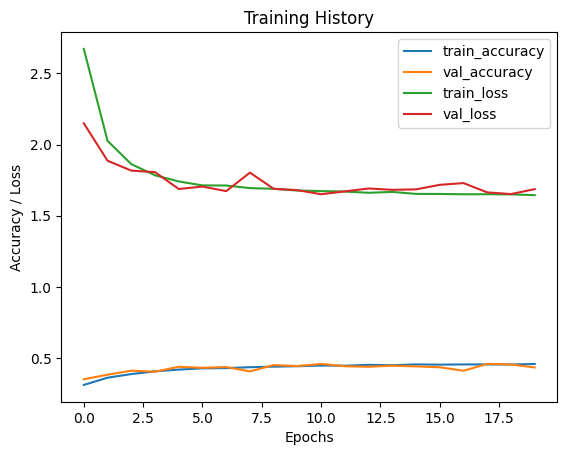

Test accuracy: 0.4347, Test loss: 1.6868

Model 3 (Advanced Model):


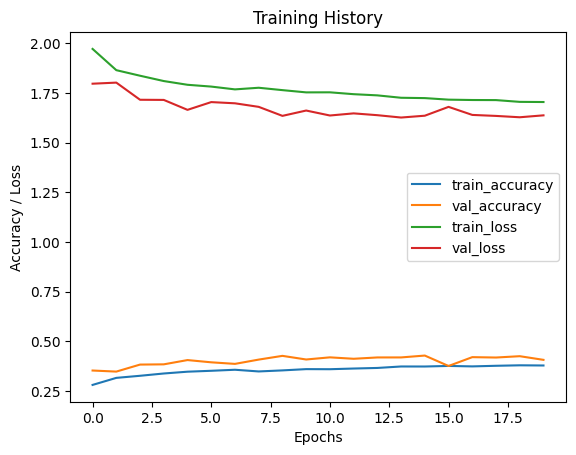

Test accuracy: 0.4070, Test loss: 1.6377


In [10]:
def train_and_plot(model, x_train, y_train, x_test, y_test, epochs=20, batch_size=64):
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=epochs, batch_size=batch_size, verbose=0)

    # Plot accuracy and loss
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Training History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy / Loss')
    plt.legend()
    plt.show()

    # Evaluate the model
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy: {accuracy:.4f}, Test loss: {loss:.4f}")

# Train and plot for all models
print("Model 1 (Basic Model):")
model_1 = create_model_1()
train_and_plot(model_1, x_train, y_train, x_test, y_test)

print("\nModel 2 (Intermediate Model):")
model_2 = create_model_2()
train_and_plot(model_2, x_train, y_train, x_test, y_test)

print("\nModel 3 (Advanced Model):")
model_3 = create_model_3()
train_and_plot(model_3, x_train, y_train, x_test, y_test)

What is your observation here?

Was this the anticipated observation?

Try reading up a little and try to identify potential reasons as to why this behaviour was exhibited.

# MLP on CIFAR-10  Dataset Observations:

- Model performance is much worse on this CIFAR-10 data than the MNIST dataset.  
- This must be due to the added dimensionality with the RGB colors in the dataset and increased complexity of the pictures.
- Aside from the RGB challenges, the main challenge is that this dataset is a library of images of different thigs (cars, dogs, objects) and not just letters.  it is inherently more complex than the MNIST dataset since these images
contain complex backgrounds and require much more processing in order to be classified correctly.
- I was not anticipating the performance to be this bad as it performed much worse than the MNIST dataset.
-The models got progressively worse the more components I added to them.
-After some research, it seems like a CNN would be a better choice for this dataset.  This is because a model with Dense/ fully connected layers is not the best approach for this dataset
because the fully connected layers do not do a good job of learning the spatial structures (edges, corners, textures, objects parts, whole parts etc...) needed to make classification for images of this nature.



# MISCELLANEOUS:

## Can you implement a model which solves any issue(s) you encountered here?

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers.schedules import ExponentialDecay

def create_cnn_model():
    lr_schedule = ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        decay_rate=0.9,
        staircase=True
    )

    model = Sequential([
        # Add an Input layer to specify the input shape
        Input(shape=(32, 32, 3)),
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.3),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.4),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss=CategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)



Model 4 (CNN Model with Conv Layers, BatchNorm, and Dropout):


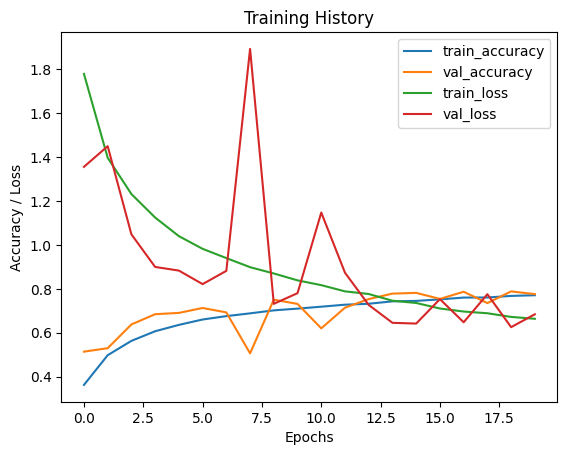

Test accuracy: 0.7758, Test loss: 0.6841


In [13]:
print("\nModel 4 (CNN Model with Conv Layers, BatchNorm, and Dropout):")
model_4 = create_cnn_model()
train_and_plot(model_4, x_train, y_train, x_test, y_test)

# CNN on CIFAR-10 Dataset Observations:

- After using a CNN on the CIFAR-10 dataset, the performance increase dramatically.
- The CNN gave me an accuracy of 77.58% vs the subpar performance I was getting with the MLP before on this data.  
- With further tuning and experimentation, this model can be even more performant.